# Explore Forgery Data

Starter notebook for inspecting authentic/forged image pairs, forged masks, and simple mask statistics.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from visualization import ForgeryDataPlotter

plotter = ForgeryDataPlotter(ROOT / "data")

In [2]:
case_ids = plotter.list_case_ids(require_authentic=True, require_mask=True)
len(case_ids), case_ids[:10]

(2377,
 ['10',
  '10015',
  '10017',
  '10030',
  '10070',
  '1008',
  '10138',
  '10139',
  '10147',
  '10152'])

In [3]:
summary = plotter.summarize_cases(case_ids[:200])
summary.describe(include="all")

,case_id,height,width,channels,mask_pixels,mask_fraction,instance_count,has_authentic_pair
count,200,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200
unique,200,NaN,NaN,NaN,NaN,NaN,NaN,1
top,10,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,200
mean,NaN,705.910000,949.205000,2.900000,4.769992e+04,0.054272,1.355000,NaN
std,NaN,678.284484,727.595995,0.436984,1.377785e+05,0.067910,0.548158,NaN
min,NaN,64.000000,113.000000,1.000000,1.870000e+02,0.000558,1.000000,NaN
25%,NaN,256.000000,375.000000,3.000000,2.332500e+03,0.006056,1.000000,NaN
50%,NaN,512.000000,696.000000,3.000000,6.528500e+03,0.023855,1.000000,NaN
75%,NaN,878.000000,1280.000000,3.000000,3.857375e+04,0.081694,2.000000,NaN


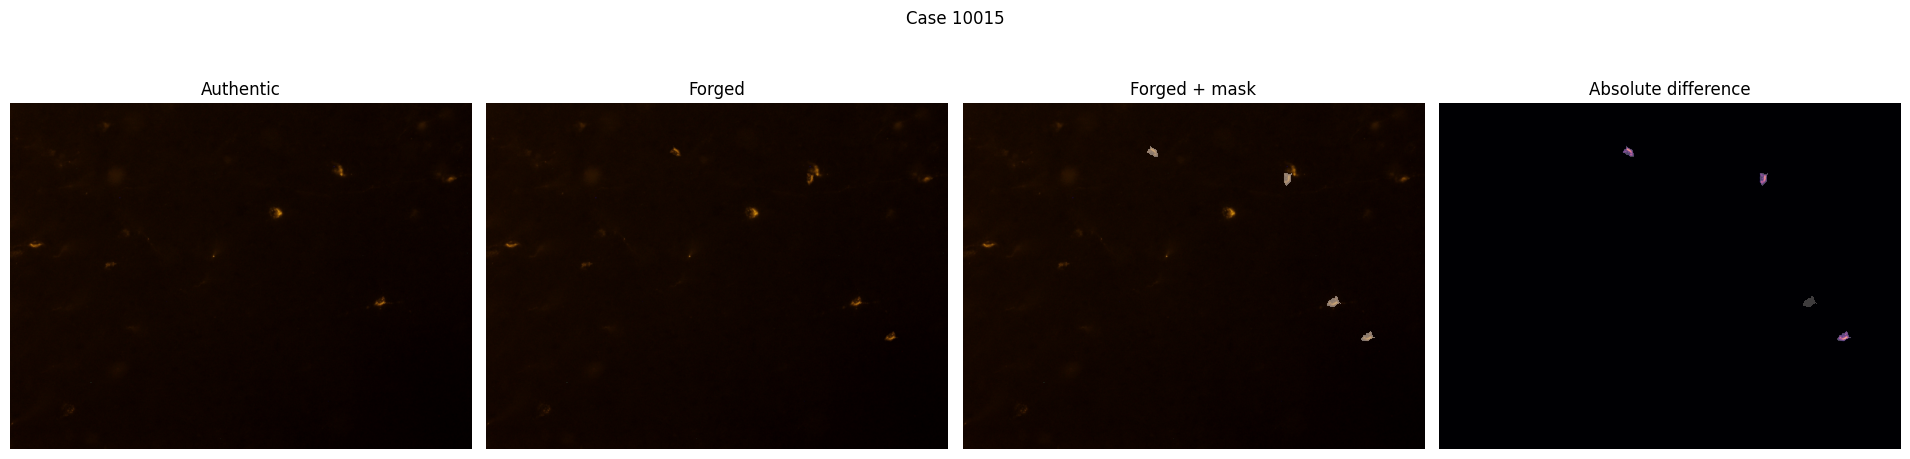

In [8]:
case_id = case_ids[1]
fig, axes = plotter.plot_case(case_id)

union pixels: 3747
target pixels: 2716
source pixels: 1031


,component,area,changed_pixels,changed_fraction,mean_diff,max_diff,is_tiny,is_target
0,1,877,830,0.946408,28.604713,111.666664,False,True
1,2,937,882,0.941302,28.883671,117.333336,False,True
2,3,1031,0,0.000000,0.000000,0.000000,False,False
3,4,902,901,0.998891,34.107906,119.333336,False,True


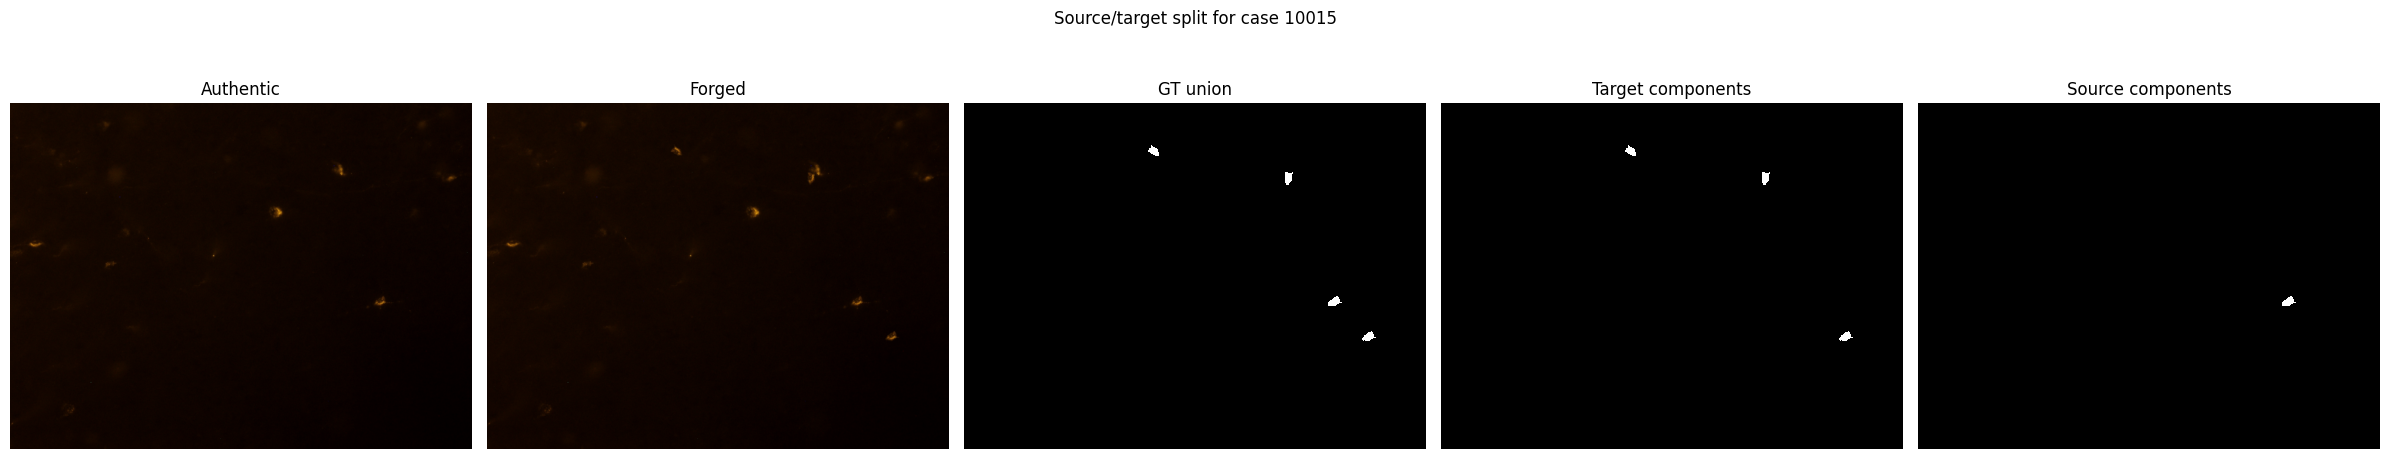

In [9]:
masks = plotter.derive_source_target_masks(case_id, diff_threshold=5.0, component_change_fraction=0.25)
print("union pixels:", int(masks.union_mask.sum()))
print("target pixels:", int(masks.target_mask.sum()))
print("source pixels:", int(masks.source_mask.sum()))
display(masks.component_scores)
fig, axes = plotter.plot_source_target_split(case_id, diff_threshold=5.0, component_change_fraction=0.25)

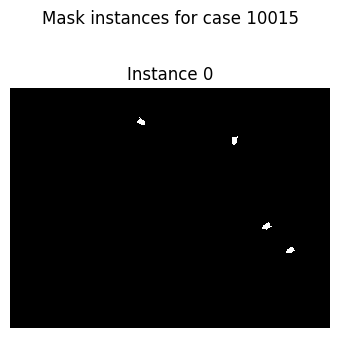

In [10]:
fig, axes = plotter.plot_instances(case_id)

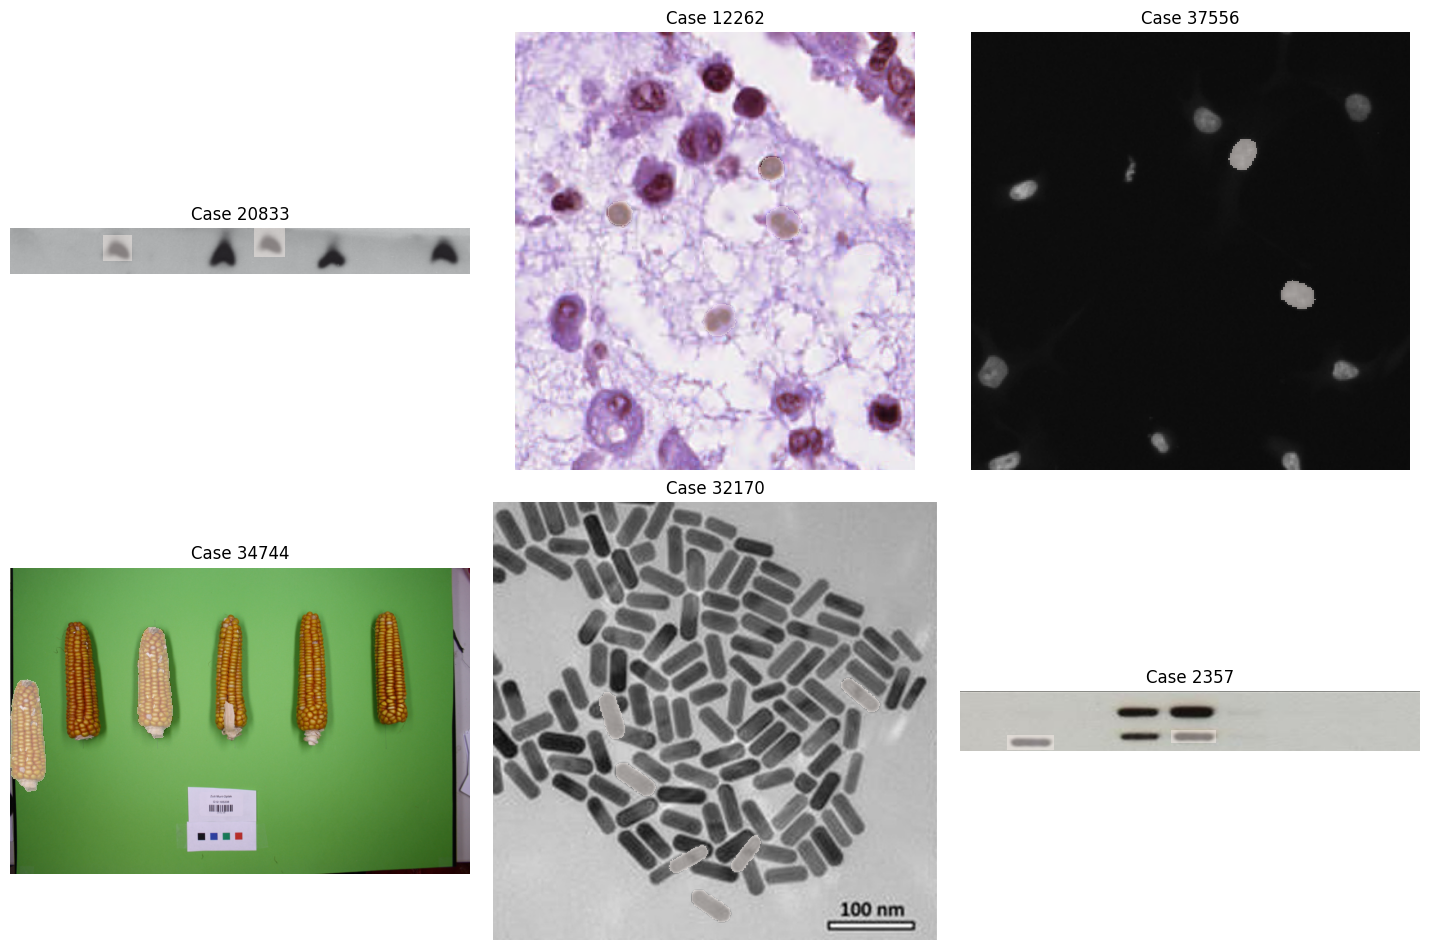

In [11]:
fig, axes = plotter.plot_random_cases(n=6, seed=42)